# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  
- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
#recuerda que .head() por default solito pone las 5 primeras filas p
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos
print()#salto de linea
print(users.isna().sum()/users.shape[0])# Proporcion de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos
print()#salto de linea
print(usage.isna().sum()/usage.shape[0])# Proporcion de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---


 
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En el data frame de **users hay 2 columnas** con faltantes **"city" y "churn_date"** con 11% y 88% respectivamente.
- En el dat frame de **usage hay** un total de **3 columnas con faltantes "date", "duration" y "lenght"** con 0.1%, 55% y 44% respectivamente.
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

- Para el data frame de users, para la columna de "city" dado que el porcentaje de faltantes es del 11% es necesaria una investigacion para saber que tipo de faltantes son y poder decidir si imputar o dejar como nulos.

- Igualmente para el data frame de user, pero la columna de "churn_date" presenta un 88% de datos faltantes, por o cual si ninguna otra columna depende de esta sugeririra ignorarla o eliminarla

- Para el data frame de usage la columnas de "date" presenta un porcentaje menor a 1% que si bien podria ser un caso simple, por lo que puede tratarse de un caso de imputación o que puede dejarse como nulo, revisaria de que tipo de faltante se trata para tomar a decision pertinente

- Y finalmente para las columnas de "duration" y "lenght" sus porcentajes son 55% y 44% respectivamente por lo que reuieren de mayor analisis para determinar la acción a tomar




### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print(users[["user_id","age"]].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` tiene valores coherentes ya que se trata de un serie de id
- La columna `age` por oto lado no tiene sentido que la edad minima sea -999 por lo que se trata de un valor invalido a checar, de ahi que la desviacion estandar sea alto iene sentido ya que solo expresa la amplitud de rangos de edad

In [13]:
# explorar columnas numéricas de usage
print(usage[["id","user_id","duration","length"]].describe())


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` estas al ser ambas serie de id parece tener valores coherentes y en el caso de `id` incluso se puede verificar la continuidad de la seríe del 1 al 40000 con el promedio de 20000 y el `user_id` conincide con el del data frame de user.
- Las columnas de `duration` y `length` no presentan ningun valor invalido sin embargo si bien la duracion de una llamada si puede ser cero, si la llamada entro pero no contestaron por ejemplo; la longitud de un mensaje de texto no podría ser cero, al menos no en la mayoria de aplicaciones de mensajeria actuales. Además la diferencia en magnitud de sus desviaciones estandar se debe a la amplitud de rango de la columna lenght  

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595




- La columna `city` tiene 7 diferentes ciudades, de las cuales "Bogotá" es la que mas de repite, con una frecuencia de 808 (22% del total de datos de la columna).
- La columna `plan` tiene unicamente 2 valores unicos, de los cuales el plan "Basico" es el que mas se repite, con una frecuencia de 2595 (64% del total de datos de la columna).




In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene unicamente 2 valores unicos de los cuales, el tipo "texto" es el que mas se repite, con una frecuencia de 22092 (55% del total de los datos de la columna)


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- 
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, existen 4 años presentes de los cuales uno, el 2026, no corresponde al periodo de registro. Este valor supera el año 2024, lo cual sugiere un error sistematico, en el registro por lo cual requerira analisis para determinar el tipo de error y accion a tomar para tratarlo 

In [19]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.unique()

array([2024.,   nan])

En `date`, existen unicamente 2 valores, "2024." y "NaN", dado que la columna presenta valores ausentes para el año 2024 no puede considerarlo como int, por lo que al tomarlo como Float agrega el punto decimal al final. Este caso requerira un analisis mas profundo para conocer que tipo de valor ausente presenta y saber como tratarlo y asi, sin valores ausentes el otro año ya puede estar como entero.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango** 

- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

-Si, en la columna de `reg_date` del data set de users, existe un año sin transcurrir y en la columna de `date` existen valores nulos (NaN) que estan afectando toda la columna

- ¿Qué harías con ellas?

-Ambos casos requieren de mayor análisis para poder decidir que hacer con ellos


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)   

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?",pd.NA)

# Verificar cambios
users["city"].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year==2026,"reg_date"] = pd.NaT


# Verificar cambios
users["reg_date"].dt.year.unique()


array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
#OJO
#La nomenclatura base para agrupar es df.groupby("col q agrupo")["col x agrupar"].funcion (sun,mean,etc)
#ejemplo df.groupby("type")["duration"].sum() da el total de minutos por cada type 

#Cuando se busca que la columna a agrupar cumpla una condicion la nomenclatura es la siguiente: 

#apply() — "aplica una operación a cada grupo"
#lambda x: — "toma cada grupo (llamado x) y haz esto:"
#Es como decir: "Agrupa por (xxxx) la columna [x]y .aplica(en cada grupo: x.condicion)"

#Puede anidarse varias condiciones como df.groupby('type')['duration'].apply(lambda x: (x.isna()) & (x > 100))

In [24]:
# Verificación MAR en usage (Missing At Random) para duration

nulos_duration = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())
print(nulos_duration)

type
call        0
text    22076
Name: duration, dtype: int64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
nulos_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())
print(nulos_length)


type
call    17896
text        0
Name: length, dtype: int64


En ambos casos tanto los valores nulos de `duration` y `length` son de tipo estructural, ya que si bien existe un patron dependiente de la columna `type`, las ausencias tienen una explicación funcional, cuando el tipo es "llamada", la longitud ( que es en caracteres) no puede tener un valor por lo que es correcto que sea nulo y de manera inversa cuando el tipo es "texto" la duracion (que es en minutos) tambien tiene lógica que sea nulo. Dicho esto, estos datos no representan un error que requiera imputarse o eliminarse, simplemente cada columna no aplica al otro tipo de registro, por lo que puede dejarse de este modo.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas

# pueden usarse cualquiera de esas 2 opciones 
# Renombrar columnas específicas
#df = df.rename(columns={'col1': 'new_col1', 'col2': 'new_col2'})
# Reemplazar todas las columnas
#df.columns = ['tipo', 'minutos', 'largo']

usage_agg.columns = ["user_id","cant_mensajes","cant_llamadas","cant_minutos_llamada"]

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios con merge (merge porque join combina usando el indice de una tabla contra el indice de la otra)
# Unir por columna común
#df_resultado = pd.merge(df1, df2, on='id')
# Unir por columnas con nombres diferentes
#df_resultado = pd.merge(df1, df2, left_on='id_1', right_on='id_2')

user_profile = pd.merge(users,usage_agg, on = "user_id")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
# Contar cuantas veces aparece cada valor unico en la columna
plan_counts = user_profile['plan'].value_counts()

# Calcular porcentaje
plan_percentage = (plan_counts / len(user_profile)) * 100
print(plan_percentage)


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.



**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [31]:
user_profile['age'].value_counts().sort_values(ascending=False).head()

47.0    115
50.0     86
30.0     81
78.0     79
36.0     74
Name: age, dtype: int64

In [32]:
user_profile['age'].value_counts().sort_values(ascending=True).head()

70.0    45
68.0    51
62.0    51
51.0    54
57.0    54
Name: age, dtype: int64

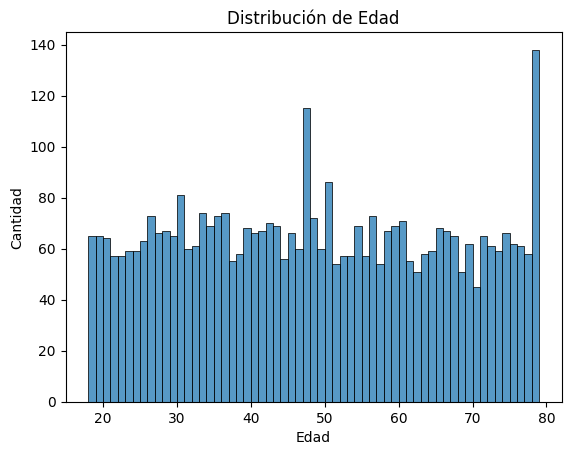

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=61, edgecolor='black')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 

La distribución de las edades relativamente uniforme, ya que las barras en el grafico son relativamente plana sin picos sumamente pronunciados (cuando el número de bins es pequeño) y si bien no parecía existir outliers evidentes, al cambiar el numero de bins puede notarse un par de picos a destacar. El pico en 47 años, el cual confirmamos con value_counts, que es la edad que mas se repite en el conteo; El segundo pico que podemos observar cercano a los 80 años es debido al número de bins, que se estan agrupando en esta ultima barra los valores de 78 y 79 años. Sin embargo no hay diferencia significativa entre media y mediana debido a que es mayor mente una distribucion uniforme

Implicación:
Ademas de demostrar la diverdad de edad en su carpeta de clientes. Destaca los segmentos demográficos a los cuales podriamos enfocar las estrategias de marketing, entre 45 y 55 años de edad como grupo principal y una estretegia mas personalizada para lograr aprovechar el segmento de entre 70 y 79 años



In [34]:
user_profile['cant_mensajes'].value_counts().sort_values(ascending=False).head()

5    655
6    643
4    626
7    509
3    462
Name: cant_mensajes, dtype: int64

In [35]:
print(user_profile['cant_mensajes'].value_counts().sort_values(ascending=True).head())
print("Mediana cant mensajes:", user_profile['cant_mensajes'].median())

17     1
16     1
15     4
14     5
13    10
Name: cant_mensajes, dtype: int64
Mediana cant mensajes: 5.0


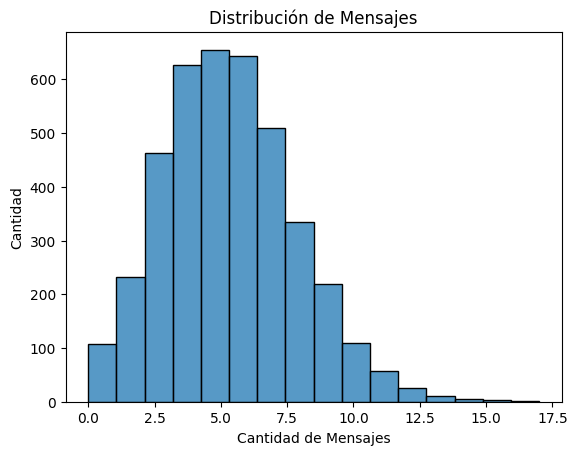

In [36]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=16, edgecolor='black')
plt.title('Distribución de Mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad')
plt.show()

💡Insights:

La distribución de los mensajes es con sesgo a la derecha, con un pico pronunciado entre lo 3 y 6 mensajes. Disminuye significativamente hacia 13 a 17 mensajes. Estos usuarios aislados con valores "extremos" de mensajes, (aunque representan menos del 1%) cuelgan la media a la derecha causando que se mayor a la mediana. Para este caso utilizar la mediana (5 mensajes) como valor tipico es mas consistente para la toma de decisiones. 

Implicación:

Ya que la mayoría de usuarios usa poco la mensajería, el enfoque para aprovechamiento del sector podria enfocarse en estrategias con la intención de activar usuarios inactivos o bien reafirmar el grupo de activos.


In [37]:
user_profile['cant_llamadas'].value_counts().sort_values(ascending=False).head()

4    757
3    696
5    649
6    491
2    466
Name: cant_llamadas, dtype: int64

In [38]:
print(user_profile['cant_llamadas'].value_counts().sort_values(ascending=True).head())
print("Mediana cant llamadas:", user_profile['cant_llamadas'].median())
print("Usuarios con 14 llamadas:",(user_profile['cant_llamadas'] == 14).sum())


13     1
15     1
12     8
11    20
10    40
Name: cant_llamadas, dtype: int64
Mediana cant llamadas: 4.0
Usuarios con 14 llamadas: 0


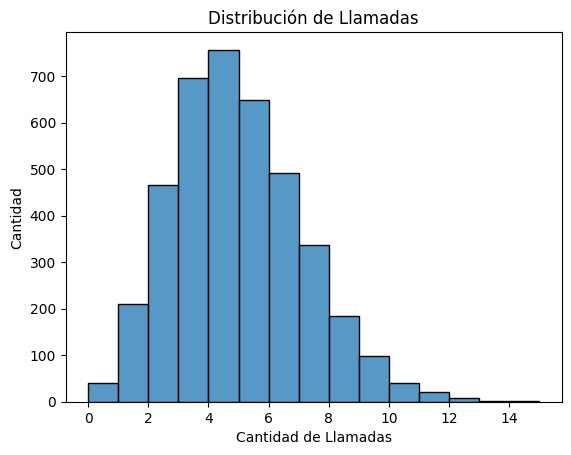

In [39]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=15, edgecolor='black')
plt.title('Distribución de Llamadas')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad')
plt.show()


💡Insights: 

La distribución de la cantidad de llamadas presenta un sesgo a la derecha, con un pico entre 3-6 llamadas. Disminuye significativamente entre las 10-15 llamadas, sesgando el promedio, por lo cual es mas confiable la mediana (4) como valor tipico a considerar. La distribución es similar a la de la cantidad de mensajes y los usuarios aislados con mayor actividad en llamadas causan el sesgo aunque representan solo el 2% de los datos totales.

Implicación:
Dado que el 76% de usuarios hace solo entre 2-6 llamadas, una estrategia a tratar podría ser crear bundles (paquetes combinados de servicios) de llamadas y mensajes para aumentar engagement de los usuarios.


In [40]:
print("Mediana cant min llamadas:", user_profile['cant_minutos_llamada'].median())

Mediana cant min llamadas: 19.78


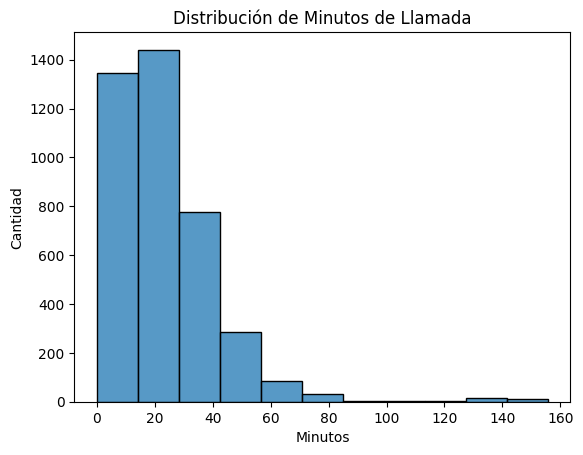

In [41]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=11, edgecolor='black')
plt.title('Distribución de Minutos de Llamada')
plt.xlabel('Minutos')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 

La distribución de minutos en llamada presenta un sesgo altamente cargado a la derecha, con un pico visible entre 0-20 minutos con aproximadamente 1600 usuarios, una caída drástica y lo que podría parecer una serie de outliers que requieres un analisis mas profundo mediante un boxplot. La cola extendida hasta 160 minutos por el sesgo modifica el promedio siendo mas confiable la mediana (19.78 min) como valor tipico. 

Implicación:

La mayoría de usuarios hace llamadas cortas menores a 20 minutos. Solo un pequeño grupo podría justificar planes ilimitados por lo que una estrategia para planes económicos (llamadas cortas) podria resultar atractiva para este sector, mientras que planes premium ilimitados para los usuarios mas activos, segmentación cada estrategia para cada tipo de cliente.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

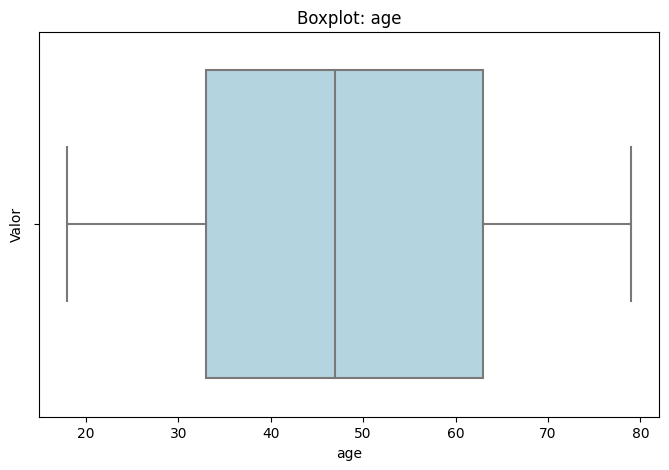

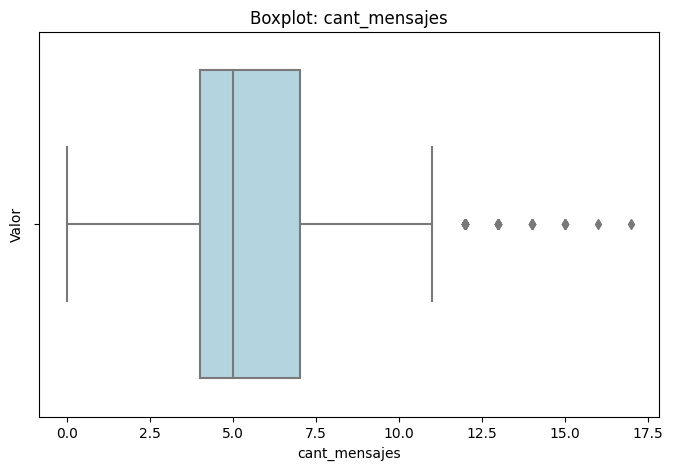

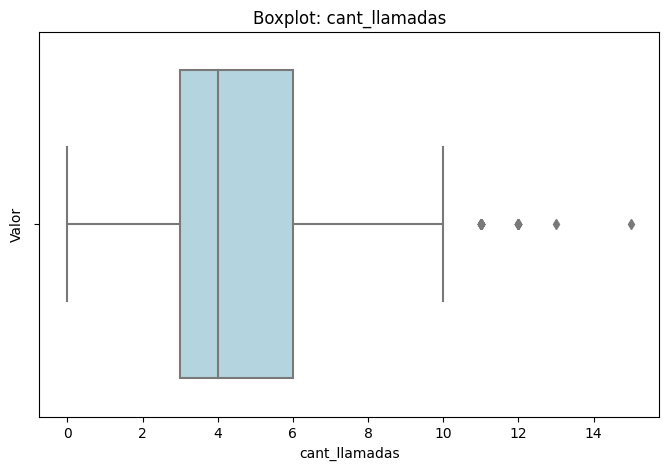

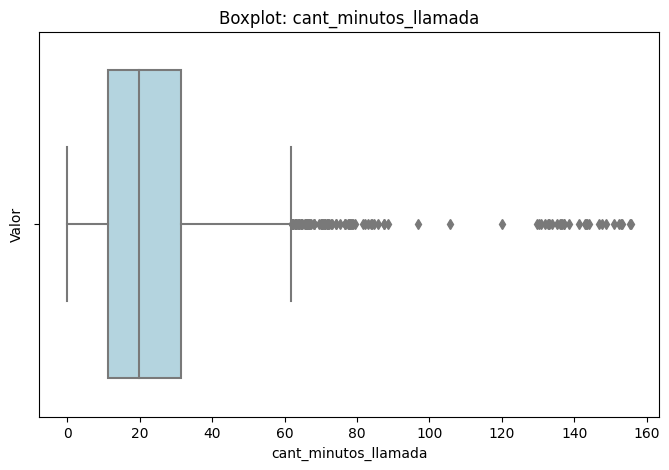

In [42]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=user_profile, x=col, color='lightblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.ylabel('Valor')
    plt.show()

💡Insights: 

- Age: no presenta outliers significativos, la edad es distribuida simetricamente entre 20 y 80 años, lo que confirma una base de clientes diversa.
  
- Cant_mensajes: presenta varios outliers que llegan de los 12 a los 17 mensajes que indica un pequeño grupo de usuarios que infla el promedio, cuando la mayoria de usuarios 75% envia menos de 7 mensajes (visible en Q3).

- Cant_llamadas: distribución similar a cantidad de mensajes, presenta outliers entre 11 y 14 llamadas. Sin embargo la mayoria de usuarios 75%, realiza menos de 6 llamadas (visible en Q3).

- Cant_minutos_llamada: Presenta muchos outliers desde los 60 min a extremosos de 160min, si bien es un pequeño grupo de usuarios sesgan el promedio, ya que la mayoria de usuarios 75%, realiza llamadas cortas menores a 30 min (visible en Q3).

In [43]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    # Calcular cuartiles
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    #limites
    limite_superior = Q3 + 1.5 * IQR
    print(f"\n{col}")
    #f antes de "" permite insertar variables dentro del texto usando {variable} y .2f es para indicar que incluya 2 decimales con float
    print(f"Límite superior:    {limite_superior:.2f}")





cant_mensajes
Límite superior:    11.50

cant_llamadas
Límite superior:    10.50

cant_minutos_llamada
Límite superior:    61.86


In [44]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- Cant_mensajes: los mantendría, ya que es un comportamiento posible sobre todo en jovenes edad incluida en la cartera de cleintes
  
- Cant_llamadas: los mantendría, ya que igualmente es un comportamiento posible, por ejemplo en personas que realicen llamadas laborales desde su personal como project manager o personal encargado de obra.

- Cant_minutos_llamada: este caso tambien lo mantendría ya que si bien en poco frecuente este comportamiento, si es posible sobre todo en personas de la tercera edad, incluidos en la cartera de clientes, ya que se sienten mas comodos mediante este método de comunicación. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso


🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [45]:
# Crear columna grupo_uso
#Puede usarse con np.select() a modo de:
#condiciones = [(df['col1_a_condicionar'] < condicion) & (df['col2_a_condicionar'] < condicion), mismo formato si se quieres condiciones diferentes para otra categorias = ['categoria1', 'categoria2']
#df['nueva_columna'] = np.select(condiciones, categorias,default="valor default=categoria_default")

user_profile["grupo_uso"] = "Alto uso" #Valor por defecto

user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), "grupo_uso" ] = 'Bajo Uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), "grupo_uso"] = 'Uso medio'

In [46]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [47]:
# Crear columna grupo_edad
# Opción con np.select() mas limio y ordenado 
#condiciones = [ df['col_'] < condicion, mismo formato para cada categoria y condicion]
#categorias = ['categoria1', 'categoria2', 'categoria3']
#df['nueva_columna'] = np.select(condiciones, categorias, default=categoria_default")


user_profile["grupo_edad"] = "Adulto Mayor" #Valor por defecto

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'




In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Uso medio,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

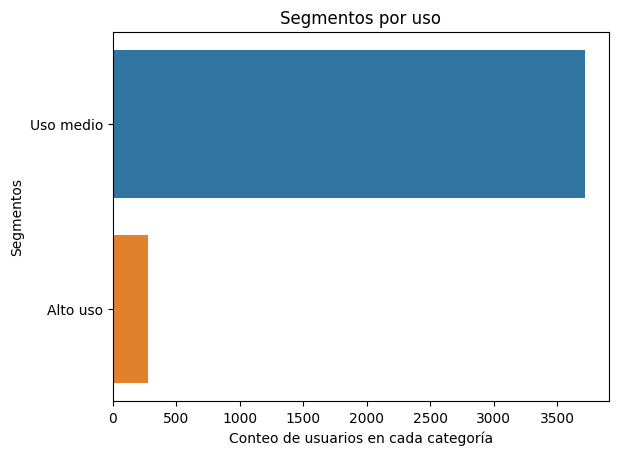

In [49]:
# Visualización de los segmentos por uso

#sns.countplot(sns.countplot(data=df, y='grupo_uso'))
#sns.countplot(data=df, y='columna_categorica', order=df['columna_categorica'].value_counts().index)

sns.countplot(data=user_profile, y='grupo_uso')
plt.title("Segmentos por uso")
plt.xlabel("Conteo de usuarios en cada categoría")
plt.ylabel('Segmentos')
plt.show()

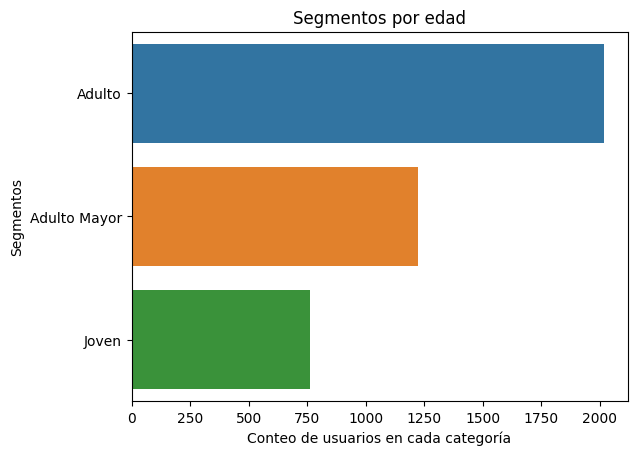

In [50]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, y='grupo_edad')
plt.title("Segmentos por edad")
plt.xlabel("Conteo de usuarios en cada categoría")
plt.ylabel('Segmentos')
plt.show()

In [54]:
print(user_profile["grupo_uso"].value_counts())
print()
print(user_profile["grupo_edad"].value_counts())

Uso medio    3721
Alto uso      278
Name: grupo_uso, dtype: int64

Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [58]:
#Para cruzar dos variables categóricas y ver cuántos clientes caen en cada combinación
#pandas tiene una herramienta pensada justo para esto: pd.crosstab()
pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'])

grupo_uso,Alto uso,Uso medio
grupo_edad,,
Adulto,153,1864
Adulto Mayor,74,1148
Joven,51,709


In [71]:
#Para cruzar dos variables categóricas y ver cuántos clientes caen en cada combinación
user_profile["metodo"] = "Ambos" #Valor por defecto

user_profile.loc[(user_profile['cant_mensajes']) > (user_profile['cant_llamadas']), 'metodo'] = 'Mensajes'
user_profile.loc[(user_profile['cant_mensajes']) < (user_profile['cant_llamadas']), 'metodo'] = 'Llamada'

pd.crosstab(user_profile['grupo_edad'], user_profile['metodo'])

metodo,Ambos,Llamada,Mensajes
grupo_edad,,,
Adulto,250,627,1140
Adulto Mayor,163,371,688
Joven,105,209,446



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 

- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Originalmente en el data frame de users había 2 columnas con valores faltantes (cuty y churn_date) con un porcentaje del total de datos de cada una de 11% y 88% respectivamente. Minetras que el data frame de usage había un total de 3 columnas con faltantes (date, duration y lenght) con 0.1%, 55% y 44% respectivamente.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Para este análisis se encontraron 2 segmentos de clientes con respecto al nivel de uso y 3 segmentos con respecto a su edad. Con respecto al nivel de uso que presentaron, tenemos un grupo reducido de 278 clientes de uso alto (que realizaron mas de 10 llamadas y mensajes durante el 2024) y un grupo amplio de 3721 clientes con uso medio (con un rango de 5 a 10 llamadas y mensajes realizados). Mientras que con respecto a la edad, tenemos un grupo de 760 clientes jovenes (menores a 30 años) los cuales usan preferentemente los mensajes sobre las llamadas (61% del total de jovenes), un grupo de 1222 clientes con la categoría de adulto mayor (con mas de 60 años) los cuales mas de la mitad usan como metodo preferente de comunicación los mensajes (56% del total de adultos mayores) y finalmente un grupo predominante de 2017 clientes adultos (con un rango de edad entre los 30 y los 60) de os cuales la mitad tienen como método de comuicación predilecto los mensajes (56%), 31% las llamadas y 12% ambos métodos. 

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Para poder contestar esta pregunta con fundamentos se realizo una tabla cruzada con ambos grupos de segmentación, edad y uso, a modo que en esta pudimos observar que el grupo mas valioso sería el grupo de adultos (de entre 30 y 60 años), ya que son el grupo con mas clientes tanto en uso alto como en uso medio. Sin embargo debido al número de clientes "adultos mayores" (de mas de 60) presentes en uso medio no lo descartaría como sector a aprovechar dentro de las campañas de marketing ya que es un sector que se puede aprovechar ya que esta apenas 716 usuarios por debajo del numero de usurios de uso medio del sector de adultos.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Encotramos pratones de uso extremo en cantidad de mensajes, llamadas y duracion de estas llamadas, sin embargo si bien estos casos describen comportamientos factibles, como se demostro anteriormente al ser poco frecuentes no generan una afeccion directa pero tampoco una oportunidad de aprovechamiento para sustentar alguna campaña o inversion debido a su baja numero de presencia. 

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Dado que mas de la mitad (57%) del total de clientes usó los mensajes de manera predilecta, las campañas e inversiones podrían enfocarse ne paqutes o planes con alguna oferta atractiva para este sector, ademas de que considerando que el 93% del total de la cartera de clientes es de uso medio (entre 5 y 10 llamadas y mensajes), podria realizarse una serie de pruebas de calidad o A/B para comprender si existe algun tipo de falla por parte del srvicio por el clual no son clientes de uso alto o bien saber que podría hacer la empresa para mejorar y convertirlos en este tipo de clientes.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- El dataframe de users presentó 2 columnas con valores faltantes: city (11%) y churn_date (88%).
- El dataframe de usage presentó 3 columnas con valores faltantes: date (0.1%), duration (55%) y length (44%).

🔍 **Segmentos por Edad**
- Clientes jóvenes menores a 30 años (760 usuarios): 61% prefieren mensajes sobre llamadas.
- Clientes adultos entre 30 y 60 años (2017 usuarios): 56% prefieren mensajes, 31% prefieren llamadas y 12% usan ambos métodos.
- Clientes adultos mayores con más de 60 años (1222 usuarios): 56% prefieren mensajes como método de comunicación predilecto.

📊 **Segmentos por Nivel de Uso**
- Grupo de uso medio: 3721 clientes que realizaron entre 5 y 10 llamadas y mensajes durante el 2024
- Grupo de uso alto: 278 clientes que realizaron más de 10 llamadas y mensajes durante el 2024


➡️ Esto sugiere que, si bien el grupo más valioso es el segmento de adultos (30-60 años) ya que representan la mayor cantidad de clientes en ambos niveles de uso (4% de uso alto y 47% de uso medio de los 3999 clientes). Los adultos mayores que son clientes de uso medio también constituyen un sector a aprovechar ya que representan un 29% del total de clientes. Los patrones de uso extremo (outliers) encontrados en mensajes, llamadas y duración de llamadas son casos factibles pero poco frecuentes, por lo que no generan impacto directo ni oportunidad de aprovechamiento para sustentar campañas o inversiones.


💡 **Recomendaciones**
- Enfocar campañas e inversiones en paquetes o planes que incuyan o resulten atractivos para el uso de mensajería, ya que más de la mitad (57%) del total de clientes usa este método de manera predilecta.
- Realizar pruebas de calidad para comprender si existen fallas en el servicio que impiden que el 93% de la cartera (usuarios de uso medio) se conviertan en clientes de uso alto, o bein identificar qué mejoras podrían implementarse para aumentar su nivel de engagement

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`